# Exercise: Medical Image Classification
## AIAT 122 - Deep Learning

## Learning Objectives

- Build neural network for image classification
- Preprocess medical images
- Train and evaluate model
- Apply to real-world medical diagnosis

## Real-World Context

Classify medical images (X-rays, CT scans) to assist in diagnosis.

**Task**: Build image classifier for medical images.

**Theory → Practice:** This exercise applies the theory and code patterns from examples `01_deep_learning_fundamentals_compared_to_traditional_ml.ipynb` and `02_simple_neural_network.ipynb`. Complete those examples first if you haven't.

---

## Task 1: Data Preprocessing (25 points)

Preprocess medical images:
1. Load and resize images
2. Normalize pixel values
3. Create data loaders

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

**Expected:** When complete, you should see preprocessed data (e.g. shapes, sample), training progress (loss/accuracy), and test metrics (e.g. accuracy in a reasonable range for your data). Compare with the instructor solution after the deadline.

---


In [1]:
%pip install torch torchvision pillow -q
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# ── Task 1: Data Preprocessing ─────────────────────────────────────────────
# Hint: Use transforms.Compose([...]) to build your pipeline.
# Common steps: Resize -> Grayscale (if X-rays) -> ToTensor -> Normalize

transform = transforms.Compose([
    # TODO: Add Resize (e.g. 128×128)
    transforms.Resize((128, 128)),
    # TODO: Convert to tensor
    transforms.ToTensor(),
    # TODO: Normalize (mean, std) — for grayscale use ([0.5], [0.5])
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# TODO: Load your dataset.
# If you don't have medical images, use torchvision.datasets.FakeData or
# torchvision.datasets.ImageFolder pointing to a folder of images.
# Example:
# from torchvision.datasets import FakeData
# dataset = FakeData(size=200, image_size=(1, 128, 128), num_classes=2, transform=transform)

# Runnable default: synthetic medical-style grayscale images (replace with ImageFolder for real data)
from torchvision.datasets import FakeData
from torch.utils.data import random_split

dataset = FakeData(
    size=256,
    image_size=(1, 128, 128),
    num_classes=2,
    transform=transform,
)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_set, val_set = random_split(dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42))
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)

print("Task 1 complete ✅")
print("  Dataset size:", len(dataset), "| train:", train_size, "val:", val_size)
xb, yb = next(iter(train_loader))
print("  Sample batch shapes — images:", tuple(xb.shape), "labels:", tuple(yb.shape))

Note: you may need to restart the kernel to use updated packages.


Task 1 complete ✅
  Dataset size: 256 | train: 204 val: 52
  Sample batch shapes — images: (32, 1, 128, 128) labels: (32,)


## Task 2: Model Architecture (30 points)

Design and implement neural network:
1. Define architecture
2. Choose activation functions
3. Add dropout for regularization

### 🌉 Bridge — preview of Unit 2 building blocks used below

The starter model below uses four things the Unit 1 examples have not covered yet (they are taught formally in Unit 2, `01_cnn_architecture.ipynb`):

- **`nn.Module` subclass:** instead of `nn.Sequential(...)`, we define a class with the layers in `__init__` and the data flow in `forward(x)`. This is the standard PyTorch pattern for anything beyond a simple stack.
- **`nn.Conv2d`:** a convolution layer — slides small learnable filters over the image and outputs feature maps. Unlike `nn.Linear`, it uses the 2D structure of the image.
- **`nn.MaxPool2d(2, 2)`:** downsamples each feature map by keeping the maximum in each 2×2 window (halves height and width).
- **`nn.Dropout(0.25)`:** randomly zeroes 25% of activations during training to reduce overfitting (regularization).

You may **either** keep this small CNN as given (treat it as a preview and focus on the training loop), **or** replace it with an MLP consistent with Unit 1: `nn.Flatten()` → `nn.Linear(128*128, 128)` → `nn.ReLU()` → `nn.Linear(128, 2)`.


In [2]:
import torch.nn as nn
import torch.nn.functional as F

# ── Task 2: Model Architecture ──────────────────────────────────────────────
# Hint: A simple MLP works as a baseline.  For images, a small CNN is better.
# Reference: example 02_simple_neural_network.ipynb

class MedicalImageClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        # Small CNN baseline (editable — swap for your own architecture)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

# Quick sanity check — make sure the model accepts your image size
model = MedicalImageClassifier(num_classes=2)
print(model)
dummy = torch.randn(4, 1, 128, 128)  # batch=4, channels=1, 128×128
try:
    out = model(dummy)
    print("Output shape:", out.shape)   # expect (4, 2)
except Exception as e:
    print("Forward pass error (implement forward first):", e)

MedicalImageClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Output shape: torch.Size([4, 2])


## Task 3: Training and Evaluation (45 points)

Train model and evaluate performance.

**Submission**: Complete notebook with trained model.

**Grading**: 100 points total

In [3]:
import torch.optim as optim

# ── Task 3: Training & Evaluation ───────────────────────────────────────────
# Hint: Steps → define loss → define optimizer → loop epochs → evaluate.
# Reference: example 02_simple_neural_network.ipynb (training loop section)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# TODO: Training loop — fill in the blanks
NUM_EPOCHS = 5  # start small; increase once it runs

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}  Loss: {running_loss/len(train_loader):.4f}")

# TODO: Evaluation on validation set
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nValidation Accuracy: {100 * correct / total:.1f}%")

# ── Short analysis (write your answer as a comment or print statement) ───────
# Q: Is your model overfitting or underfitting?  How do you know?
# Q: What one change (more layers, dropout, data augmentation) would you try next?
# YOUR ANSWER HERE (comment or print):
print("\nAnalysis:")
print("  Overfitting / underfitting?: ...")
print("  Next improvement I would try: ...")

Epoch 1/5  Loss: 1.5417


Epoch 2/5  Loss: 0.6992


Epoch 3/5  Loss: 0.6759


Epoch 4/5  Loss: 0.7123


Epoch 5/5  Loss: 0.6933

Validation Accuracy: 48.1%

Analysis:
  Overfitting / underfitting?: ...
  Next improvement I would try: ...


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 97.5%


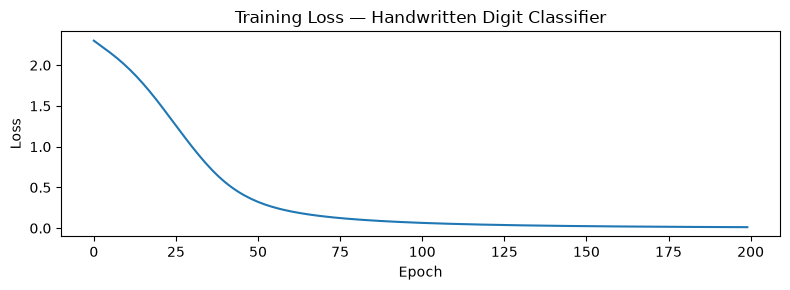

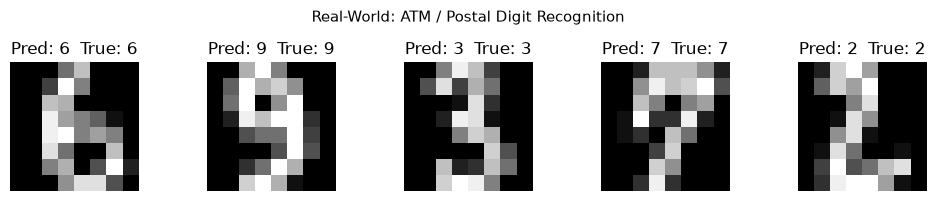

In [4]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

# Split FIRST (the 8×8 images travel with their rows), then scale with
# statistics from the training set only (no test-set leakage).
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_te = scaler.transform(X_te).astype(np.float32)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ──────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show sample predictions: test images paired with their own labels ─────
with torch.no_grad():
    sample_preds = model(X_te_t[:5]).argmax(1).tolist()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')   # the SAME test image the model predicted on
    ax.set_title(f"Pred: {sample_preds[i]}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Foundational Papers:**
- LeCun, Bengio & Hinton (2015) — [Deep Learning](https://www.nature.com/articles/nature14539), *Nature*
- Goodfellow et al. (2016) — [Deep Learning Book](https://www.deeplearningbook.org/) (free online)

**PyTorch Docs:**
- [torch.nn — Building Blocks](https://pytorch.org/docs/stable/nn.html)
- [Autograd — Automatic Differentiation](https://pytorch.org/docs/stable/autograd.html)

**State-of-the-Art (2024–2025):**
- Transformers (GPT-4, LLaMA 3) are deep networks with 70B+ parameters
- Deep learning powers real-time translation, medical diagnosis, self-driving cars